In [3]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

In [4]:
width, height = 200, 200

# Crear imagen
image = Image.new('RGB', (width, height), 'white')
pixels = image.load()

### Algoritmo de Bresenham

In [5]:
def bresenham(x0, y0, x1, y1):
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy

    while True:
        pixels[x0, y0] = (255, 0, 0)
        if x0 == x1 and y0 == y1:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
        x0 += sx
        if e2 < dx:
            err += dx
        y0 += sy


### Algoritmo de punto medio

In [6]:
def midpoint_circle(x0, y0, radius):

    x = radius
    y = 0
    p = 1 - radius

    while x >= y:

        puntos = [
            (x, y), (y, x), (-x, y), (-y, x),
            (-x, -y), (-y, -x), (x, -y), (y, -x)
        ]

        for dx, dy in puntos:
            px = x0 + dx
            py = y0 + dy

            if 0 <= px < width and 0 <= py < height:
                pixels[px, py] = (0, 0, 255)

        y += 1

        if p <= 0:
            p = p + 2*y + 1
        else:
            x -= 1
            p = p + 2*y - 2*x + 1

### Rasterización triángulo

In [7]:
def fill_triangle(p1, p2, p3):

    pts = sorted([p1, p2, p3], key=lambda p: p[1])
    (x1, y1), (x2, y2), (x3, y3) = pts

    def interpolate(y0, y1, x0, x1):
        if y1 - y0 == 0:
            return []
        return [int(x0 + (x1-x0)*(y-y0)/(y1-y0)) for y in range(y0, y1)]

    x12 = interpolate(y1, y2, x1, x2)
    x23 = interpolate(y2, y3, x2, x3)
    x13 = interpolate(y1, y3, x1, x3)

    x_left = x12 + x23

    for y, xl, xr in zip(range(y1, y3), x13, x_left):

        for x in range(min(xl, xr), max(xl, xr)):

            if 0 <= x < width and 0 <= y < height:
                pixels[x, y] = (0, 255, 0)

### Pruebas

In [13]:
bresenham(10, 10, 180, 180)

In [14]:
midpoint_circle(100, 100, 40)

In [15]:
fill_triangle((30, 50), (100, 150), (160, 60))

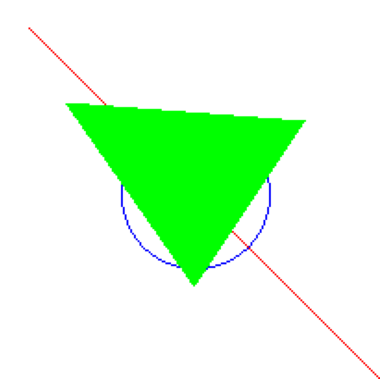

In [16]:
plt.imshow(image)
plt.axis('off')
plt.show()
image.save("../media/resultado.png")